# Marketing Campaign Analysis

## Applied Data Science with Python — Course-End Project

### Objective
Perform exploratory data analysis and hypothesis testing to understand the factors influencing customer acquisition and marketing campaign performance.

# 1. Import Libraries

The libraries required for data manipulation, numerical analysis, and data visualization are imported.

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

# 2. Load the Dataset

The marketing campaign dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
df = pd.read_csv(
    r"C:\Users\juanb\Documents\Python_Course_End_Projects\marketing_campaign\data\marketing_data.csv"
)

# 3. Initial Data Inspection

The dataset is inspected to understand its structure, column names, data types, and overall completeness before cleaning and analysis.

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [6]:
df.shape

(2240, 28)

In [7]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 ' Income ',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   2240 non-null   int64
 1   Year_Birth           2240 non-null   int64
 2   Education            2240 non-null   str  
 3   Marital_Status       2240 non-null   str  
 4    Income              2216 non-null   str  
 5   Kidhome              2240 non-null   int64
 6   Teenhome             2240 non-null   int64
 7   Dt_Customer          2240 non-null   str  
 8   Recency              2240 non-null   int64
 9   MntWines             2240 non-null   int64
 10  MntFruits            2240 non-null   int64
 11  MntMeatProducts      2240 non-null   int64
 12  MntFishProducts      2240 non-null   int64
 13  MntSweetProducts     2240 non-null   int64
 14  MntGoldProds         2240 non-null   int64
 15  NumDealsPurchases    2240 non-null   int64
 16  NumWebPurchases      2240 non-null 

# 4. Examine Income and Customer Date

The `Income` and `Dt_Customer` columns are examined to determine whether they were imported with the appropriate data types and to identify any missing values that require treatment.

In [33]:
df[["Income", "Dt_Customer"]].dtypes

Income                float64
Dt_Customer    datetime64[us]
dtype: object

In [ ]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 ' Income ',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country']

In [ ]:
for column in df.columns:
    print(repr(column))

'ID'
'Year_Birth'
'Education'
'Marital_Status'
' Income '
'Kidhome'
'Teenhome'
'Dt_Customer'
'Recency'
'MntWines'
'MntFruits'
'MntMeatProducts'
'MntFishProducts'
'MntSweetProducts'
'MntGoldProds'
'NumDealsPurchases'
'NumWebPurchases'
'NumCatalogPurchases'
'NumStorePurchases'
'NumWebVisitsMonth'
'AcceptedCmp3'
'AcceptedCmp4'
'AcceptedCmp5'
'AcceptedCmp1'
'AcceptedCmp2'
'Response'
'Complain'
'Country'


### Clean Column Names

Column names are cleaned by removing leading and trailing whitespace to ensure that variables can be referenced consistently throughout the analysis.

In [15]:
df.columns = df.columns.str.strip()

In [16]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country']

In [17]:
df[["Income", "Dt_Customer"]].dtypes

Income         str
Dt_Customer    str
dtype: object

In [23]:
df["Income"].head(10)

0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
5    71691.0
6    63564.0
7    44931.0
8    65324.0
9    65324.0
Name: Income, dtype: float64

# 5. Clean the Income Column

The `Income` column was imported as text because the values contain dollar signs and commas. These formatting characters are removed, and the column is converted to a numeric data type for analysis.

In [19]:
df["Income"] = (
    df["Income"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [21]:
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")

In [22]:
df["Income"].dtype

dtype('float64')

In [24]:
df["Income"].isnull().sum()

np.int64(24)

# 6. Clean the Customer Date Column

The `Dt_Customer` column is examined and converted from text into a datetime data type so that it can be used correctly in date-based analysis.

In [31]:
df["Dt_Customer"].head(10)



0   2014-06-16
1   2014-06-15
2   2014-05-13
3   2014-05-11
4   2014-04-08
5   2014-03-17
6   2014-01-29
7   2014-01-18
8   2014-01-11
9   2014-01-11
Name: Dt_Customer, dtype: datetime64[us]

In [30]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%m/%d/%y"
)

# 7. Clean Categorical Variables

The `Education` and `Marital_Status` variables are examined for inconsistent or redundant categories before they are used to estimate missing Income values.

In [32]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [36]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

### Clean Marital Status Categories

The `Marital_Status` column contains several uncommon categories (`Alone`, `YOLO`, and `Absurd`). These categories are consolidated into the `Single` category to create more consistent groups for analysis and Income imputation.

In [35]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single",
    "YOLO": "Single",
    "Absurd": "Single"
})

# 8. Impute Missing Income Values

Missing `Income` values are estimated using the average income of customers with the same `Education` and `Marital_Status`. This approach preserves differences in income that may exist between demographic groups.

In [37]:
df[df["Income"].isnull()][["Education", "Marital_Status", "Income"]]

,Education,Marital_Status,Income
134,PhD,Married,NaN
262,Graduation,Married,NaN
394,PhD,Together,NaN
449,Graduation,Single,NaN
525,PhD,Married,NaN
590,2n Cycle,Married,NaN
899,Master,Together,NaN
997,Graduation,Single,NaN
1096,2n Cycle,Single,NaN
1185,Master,Together,NaN


In [38]:
group_income_mean = df.groupby(
    ["Education", "Marital_Status"]
    )["Income"].mean()

In [42]:
group_income_mean

0       54526.042017
1       51365.633065
2       50800.258741
3       55758.480702
4       51365.633065
            ...     
2235    53096.615385
2236    46201.100000
2237    54526.042017
2238    50800.258741
2239    58138.031579
Name: Income, Length: 2240, dtype: float64

In [40]:
group_income_mean = df.groupby(
    ["Education", "Marital_Status"]
    )["Income"].transform("mean")

In [41]:
group_income_mean.head(10)

0    54526.042017
1    51365.633065
2    50800.258741
3    55758.480702
4    51365.633065
5    53039.666667
6    46201.100000
7    55758.480702
8    58138.031579
9    58138.031579
Name: Income, dtype: float64

In [43]:
df[df["Income"].isnull()][["Education", "Marital_Status"]].assign(
    Group_Mean_Income=group_income_mean
)

,Education,Marital_Status,Group_Mean_Income
134,PhD,Married,58138.031579
262,Graduation,Married,50800.258741
394,PhD,Together,56041.422414
449,Graduation,Single,51365.633065
525,PhD,Married,58138.031579
590,2n Cycle,Married,46201.100000
899,Master,Together,52109.009804
997,Graduation,Single,51365.633065
1096,2n Cycle,Single,53673.944444
1185,Master,Together,52109.009804


In [44]:
missing_mask = df["Income"].isnull()

In [45]:
df.loc[missing_mask, "Income"] = group_income_mean[missing_mask]

In [47]:
df["Income"].isnull().sum()

np.int64(0)

# 9. Feature Engineering

New variables are created from the existing dataset to support exploratory analysis and hypothesis testing.

In [63]:
df[["Kidhome", "Teenhome"]].head(10)

,Kidhome,Teenhome
0,0,0
1,0,0
2,0,1
3,1,1
4,1,0
5,0,0
6,0,0
7,0,1
8,0,1
9,0,1


In [64]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [65]:
df[["Kidhome", "Teenhome", "Total_Children"]].head(10)

,Kidhome,Teenhome,Total_Children
0,0,0,0
1,0,0,0
2,0,1,1
3,1,1,2
4,1,0,1
5,0,0,0
6,0,0,0
7,0,1,1
8,0,1,1
9,0,1,1


## 9.2 Customer Age

Customer age is derived from `Year_Birth`. The appropriate reference year is determined from the time period represented by the customer enrollment data.

In [66]:
df["Dt_Customer"].min()

Timestamp('2012-07-30 00:00:00')

In [67]:
df["Dt_Customer"].max()

Timestamp('2014-06-29 00:00:00')

In [68]:
df["Age"] = 2014 -df["Year_Birth"]

In [69]:
df[["Year_Birth", "Age"]].head(10)

,Year_Birth,Age
0,1970,44
1,1961,53
2,1958,56
3,1967,47
4,1989,25
5,1958,56
6,1954,60
7,1967,47
8,1954,60
9,1954,60


## 9.3 Total Customer Spending

A `Total_Spending` variable is created by combining the amount spent across all product categories.

In [70]:
df[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,189,104,379,111,189,218
1,464,5,64,7,0,37
2,134,11,59,15,2,30
3,10,0,1,0,0,0
4,6,16,24,11,0,34


In [71]:
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

In [72]:
df[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "Total_Spending"
]].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
0,189,104,379,111,189,218,1190
1,464,5,64,7,0,37,577
2,134,11,59,15,2,30,251
3,10,0,1,0,0,0,11
4,6,16,24,11,0,34,91


## 9.4 Total Purchases

A `Total_Purchases` variable is created by combining the number of purchases made through the web, catalog, and physical store channels.

In [73]:
df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]].head()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,4,4,6
1,7,3,7
2,3,2,5
3,1,0,2
4,3,1,2


In [75]:
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

In [76]:
df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Purchases"
]].head()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases
0,4,4,6,14
1,7,3,7,17
2,3,2,5,10
3,1,0,2,3
4,3,1,2,6


# 10. Distribution and Outlier Analysis

Histograms and box plots are used to examine the distributions of numerical variables and identify potential outliers that may require further investigation or treatment.

## 10.1 Income Distribution

The distribution of customer income is examined using a histogram to understand the range, concentration, and shape of the data.

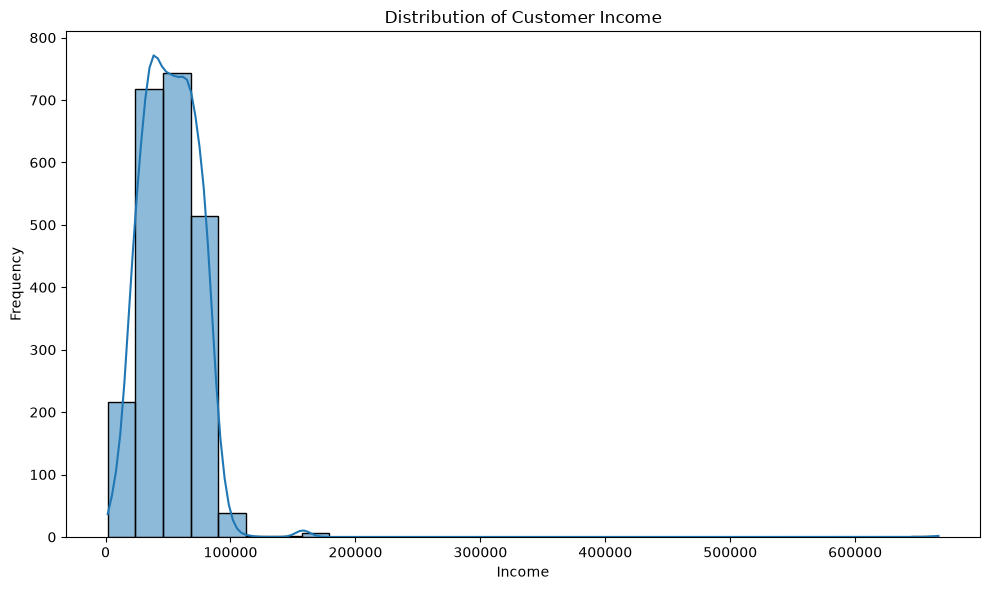

In [77]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Income',
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 10.2 Income Outlier Analysis

A box plot is used to identify potential outliers in customer income. Observations that appear unusually high or low are investigated before deciding whether any treatment is necessary.

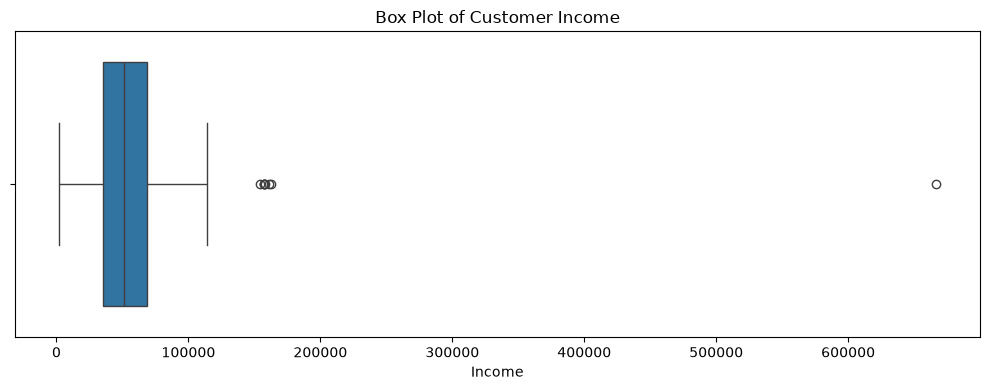

In [80]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='Income'
)

plt.title("Box Plot of Customer Income")
plt.xlabel("Income")

plt.tight_layout()
plt.show()

### Identify Income Outliers Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential income outliers. Values below 1.5 times the IQR from the first quartile or above 1.5 times the IQR from the third quartile are considered potential outliers.

In [81]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [82]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 35538.75
Q3: 68289.75
IQR: 32751.0
Lower Bound: -13587.75
Upper Bound: 117416.25


In [ ]:
income_outliers = df[
    (df["Income"] < lower_bound) |
    (df["Income"] > upper_bound)
]

In [84]:
income_outliers[[
    "Income",
    "Education",
    "Marital_Status"
]].sort_values("Income")

,Income,Education,Marital_Status
1826,153924.0,Graduation,Divorced
1925,156924.0,PhD,Married
325,157146.0,Graduation,Together
2204,157243.0,PhD,Married
853,157733.0,Master,Together
497,160803.0,PhD,Married
731,162397.0,PhD,Together
527,666666.0,Graduation,Together


### Investigate Extreme Income Values

The IQR method identified several high-income observations. Because statistical outliers are not necessarily data errors, the observations are examined before treatment. Particular attention is given to the extreme income value of 666,666.

In [85]:
df[df["Income"] == 666666]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Children,Age,Total_Spending,Total_Purchases
527,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,0,0,0,0,0,SA,1,37,62,7


### Treat Extreme Income Outlier

The income value of 666,666 is substantially higher than all other observations and is inconsistent with the customer's relatively low spending and purchasing activity. Rather than removing the customer record, the extreme income value is treated as anomalous and replaced using the mean income of customers with the same Education and Marital Status, excluding the extreme observation itself.

In [86]:
replacement_income = df.loc[
    (df["Education"] == "Graduation")
    & (df["Marital_Status"] == "Together")
    & (df["Income"] != 666666),
    "Income"
].mean()

replacement_income

np.float64(53614.94554632194)

In [87]:
df.loc[df["Income"] == 666666, "Income"] = replacement_income

In [88]:
df.loc[df["ID"] == 9432, [
    "ID",
    "Education",
    "Marital_Status",
    "Income",
    "Total_Spending",
    "Total_Purchases"
]]

,ID,Education,Marital_Status,Income,Total_Spending,Total_Purchases
527,9432,Graduation,Together,53614.945546,62,7


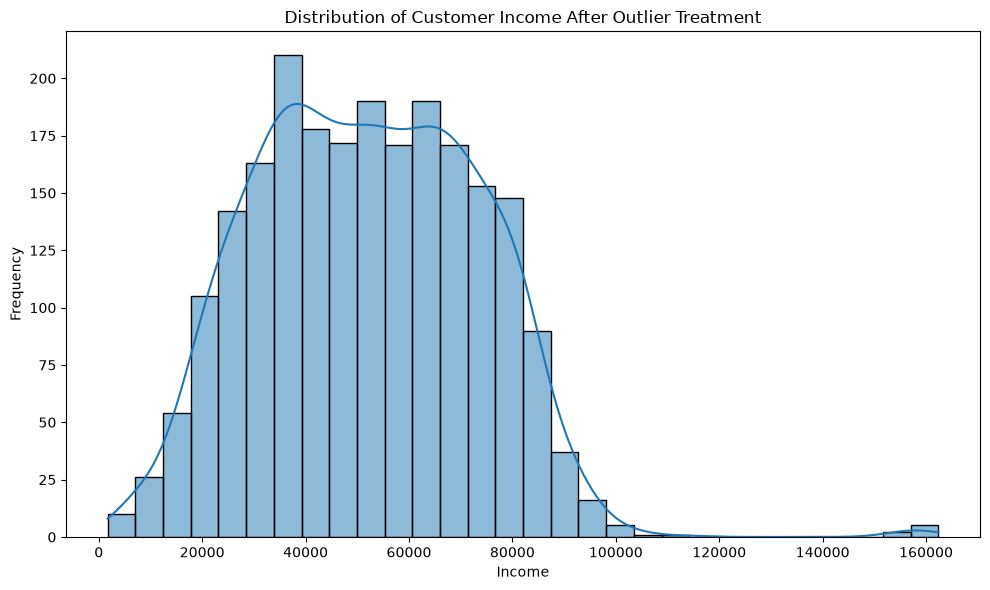

In [89]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Income",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Income After Outlier Treatment")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

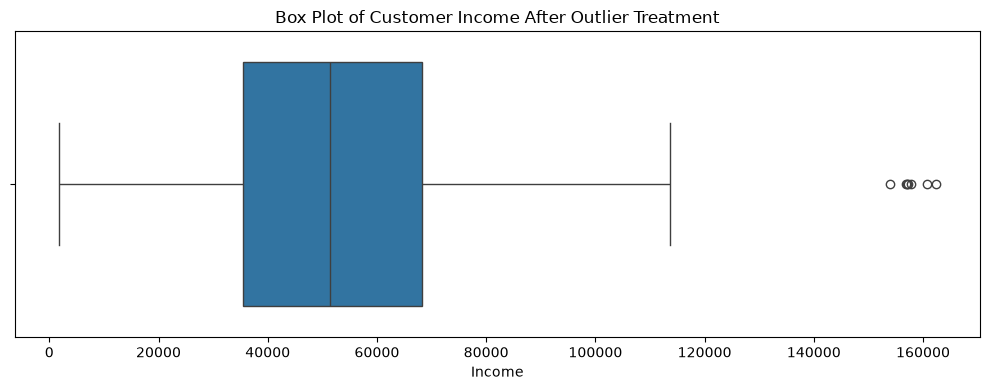

In [90]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Income"
)

plt.title("Box Plot of Customer Income After Outlier Treatment")
plt.xlabel("Income")

plt.tight_layout()
plt.show()

## 10.3 Age Distribution and Outlier Analysis

The distribution of customer age is examined using a histogram and box plot to identify potential unusual or implausible age values.

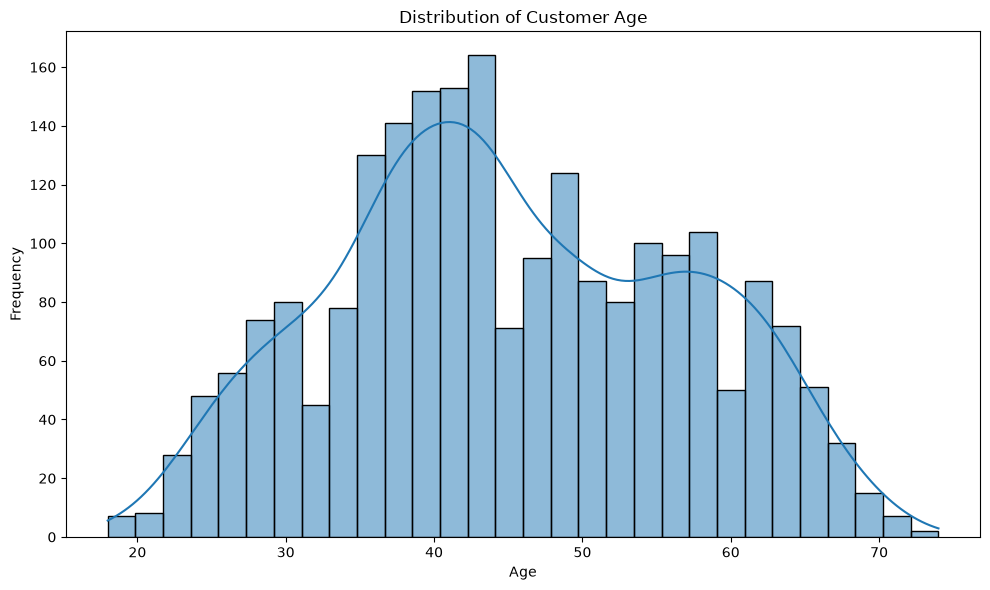

In [103]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

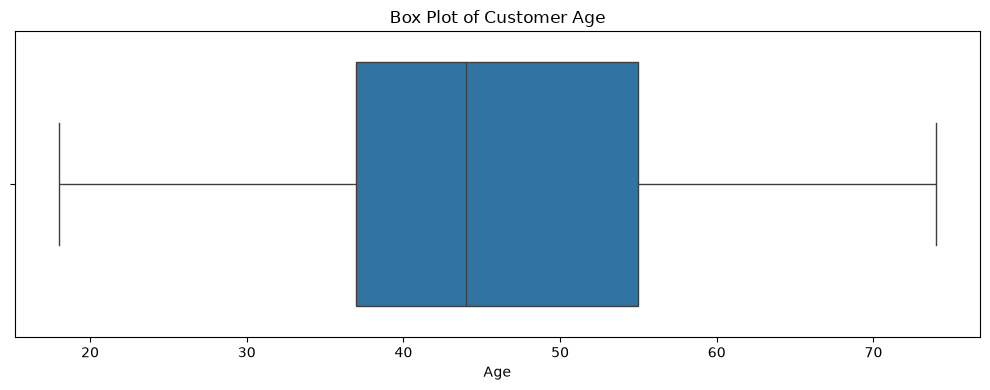

In [102]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Box Plot of Customer Age")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

### Investigate Extreme Age Values

The age distribution contains several observations above 100 years old that are substantially separated from the rest of the customer population. These observations are examined using their original birth year and customer information before determining whether treatment is necessary.

In [93]:
df.loc[
    df["Age"] > 100,
    ["ID", "Year_Birth", "Age", "Education", "Marital_Status", "Income"]
]

,ID,Year_Birth,Age,Education,Marital_Status,Income
513,11004,1893,121,2n Cycle,Single,60182.0
827,1150,1899,115,PhD,Together,83532.0
2233,7829,1900,114,2n Cycle,Divorced,36640.0


In [94]:
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

In [95]:
print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)
print("Lower Bound:", lower_bound_age)
print("Upper Bound:", upper_bound_age)

Q1: 37.0
Q3: 55.0
IQR: 18.0
Lower Bound: 10.0
Upper Bound: 82.0


### Treat Extreme Age Outliers

Three customers have ages above the IQR upper bound of 82 years, with recorded birth years of 1893, 1899, and 1900. These observations are substantially separated from the rest of the customer population and cannot be reliably corrected from the available data. Because they represent only a small portion of the dataset, these records are removed from further analysis.

In [96]:
df = df[df["Age"] <= upper_bound_age].copy()

In [100]:
df.shape

(2237, 32)

In [98]:
df["Age"].max()

np.int64(74)

In [99]:
df[df["Age"] > 100]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Children,Age,Total_Spending,Total_Purchases


## 10.4 Total Spending Distribution

The distribution of total customer spending is examined to understand purchasing behavior and identify potential unusually high or low spending values.

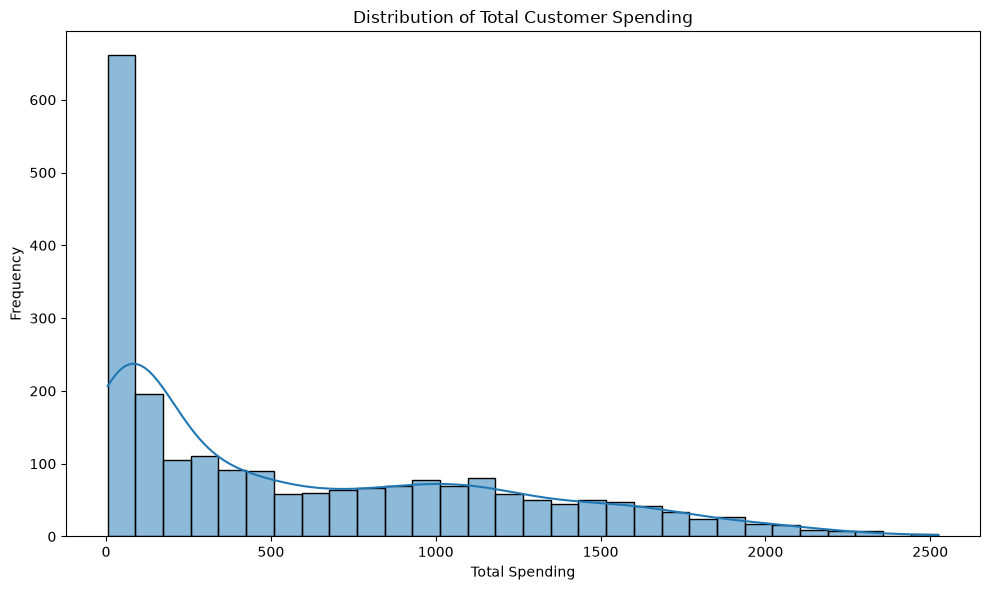

In [110]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Total_Spending",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

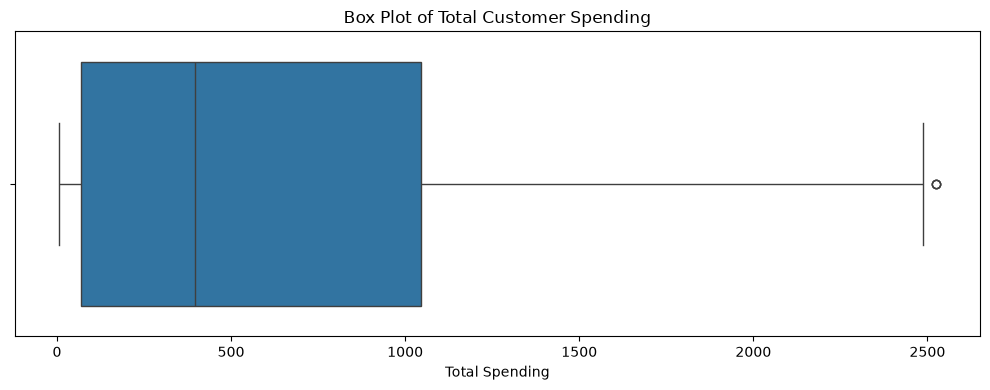

In [111]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Total_Spending"
)

plt.title("Box Plot of Total Customer Spending")
plt.xlabel("Total Spending")

plt.tight_layout()
plt.show()

In [112]:
Q1_spending = df["Total_Spending"].quantile(0.25)
Q3_spending = df["Total_Spending"].quantile(0.75)

IQR_spending = Q3_spending - Q1_spending

lower_bound_spending = Q1_spending - 1.5 * IQR_spending
upper_bound_spending = Q3_spending + 1.5 * IQR_spending

In [113]:
print("Q1:", Q1_spending)
print("Q3:", Q3_spending)
print("IQR:", IQR_spending)
print("Lower Bound:", lower_bound_spending)
print("Upper Bound:", upper_bound_spending)

Q1: 69.0
Q3: 1045.0
IQR: 976.0
Lower Bound: -1395.0
Upper Bound: 2509.0


In [114]:
spending_outliers = df.loc[
    df["Total_Spending"] > upper_bound_spending,
    [
        "ID",
        "Income",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "Total_Spending"
    ]
]

spending_outliers

,ID,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
671,5735,90638.0,1156,120,915,94,144,96,2525
672,5350,90638.0,1156,120,915,94,144,96,2525
1404,1763,87679.0,1259,172,815,97,148,33,2524


### Total Spending Outlier Assessment

The IQR method identified three customers with total spending slightly above the upper bound of 2,509. Examination of the individual product categories showed that these totals resulted from plausible spending across multiple product categories rather than an obvious data error. Therefore, these observations were retained for further analysis.

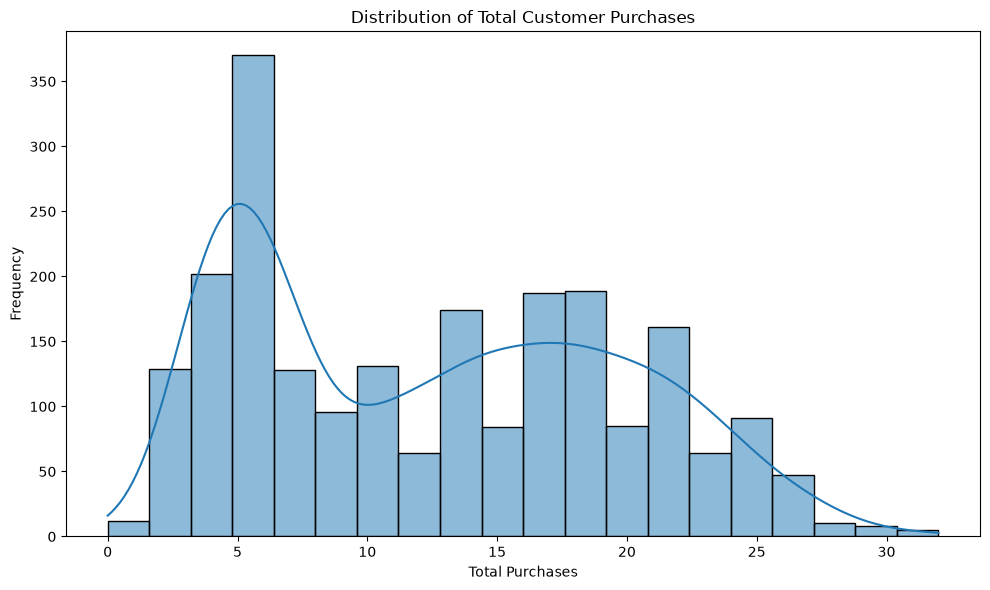

In [115]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Total_Purchases",
    bins=20,
    kde=True
)

plt.title("Distribution of Total Customer Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

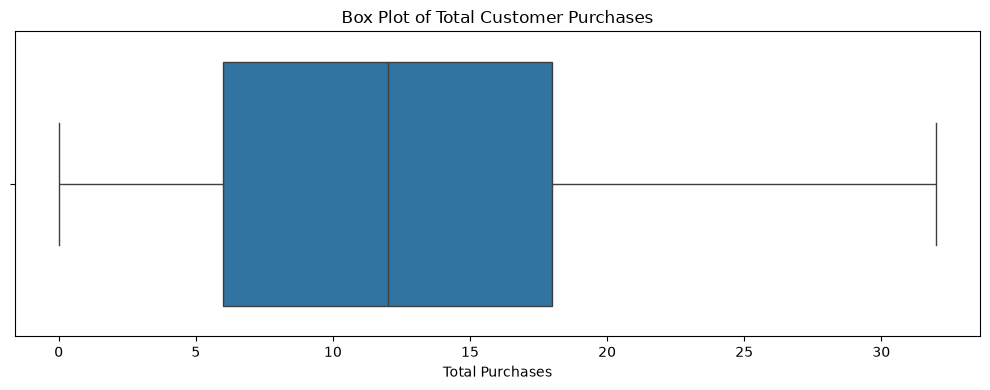

In [116]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Total_Purchases"
)

plt.title("Box Plot of Total Customer Purchases")
plt.xlabel("Total Purchases")

plt.tight_layout()
plt.show()

### Total Purchases Assessment

The distribution of total purchases shows variation in customer purchasing frequency, with concentrations among both lower-frequency and higher-frequency purchasers. The box plot does not identify any significant outliers, so no outlier treatment is required for `Total_Purchases`.

# 11. Categorical Variable Encoding

Categorical variables are examined to determine whether ordinal encoding or one-hot encoding is appropriate based on whether the categories have a meaningful order.

In [118]:
df.select_dtypes(include=["str"]).columns

Index(['Education', 'Marital_Status', 'Country'], dtype='str')

In [119]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [ ]:
education_order = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}

## 11.1 Ordinal Encoding

The `Education` variable represents levels of educational attainment and is encoded using ordered numerical values.

In [121]:
education_order

{'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}

In [122]:
df["Education_Encoded"] = df["Education"].map(education_order)

In [123]:
df[["Education", "Education_Encoded"]].head(10)

,Education,Education_Encoded
0,Graduation,2
1,Graduation,2
2,Graduation,2
3,Graduation,2
4,Graduation,2
5,PhD,4
6,2n Cycle,1
7,Graduation,2
8,PhD,4
9,PhD,4


In [124]:
df["Education_Encoded"].isnull().sum()

np.int64(0)

In [132]:
marital_encoded =pd.get_dummies(
    df["Marital_Status"],
    prefix="Marital",
    dtype=int
)

In [133]:
marital_encoded.head(10)

,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow
0,1,0,0,0,0
1,0,0,1,0,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0
5,0,0,1,0,0
6,0,1,0,0,0
7,0,0,0,1,0
8,0,1,0,0,0
9,0,1,0,0,0


## 11.2 One-Hot Encoding

The `Marital_Status` and `Country` variables are nominal categorical variables because their categories do not have a meaningful order. One-hot encoding is used to represent these categories numerically without introducing an artificial ranking.

In [130]:
df["Country"].value_counts()

Country
SP     1094
SA      336
CA      268
AUS     160
IND     147
GER     120
US      109
ME        3
Name: count, dtype: int64

In [134]:
country_encoded = pd.get_dummies(
    df["Country"],
    prefix="Country",
    dtype=int
)

In [135]:
country_encoded.head(10)

,Country_AUS,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US
0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0
5,0,0,0,0,0,0,1,0
6,0,0,1,0,0,0,0,0
7,0,0,0,0,0,0,1,0
8,0,0,0,0,0,0,0,1
9,0,0,0,1,0,0,0,0


## 11.3 Create Encoded Dataset

A copy of the cleaned dataset is created for numerical analysis. The one-hot encoded marital status and country variables are added to this copy while preserving the original dataset for later interpretation and visualization.

In [136]:
df_encoded = df.copy()

In [137]:
df_encoded.shape

(2237, 33)

In [138]:
df_encoded = pd.concat(
    [df_encoded, marital_encoded, country_encoded],
    axis=1
)

In [139]:
df_encoded.shape

(2237, 46)

In [140]:
df_encoded.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Response',
 'Complain',
 'Country',
 'Total_Children',
 'Age',
 'Total_Spending',
 'Total_Purchases',
 'Education_Encoded',
 'Marital_Divorced',
 'Marital_Married',
 'Marital_Single',
 'Marital_Together',
 'Marital_Widow',
 'Country_AUS',
 'Country_CA',
 'Country_GER',
 'Country_IND',
 'Country_ME',
 'Country_SA',
 'Country_SP',
 'Country_US']

In [141]:
df_encoded[
    [
        "Education",
        "Education_Encoded",
        "Marital_Status",
        "Marital_Married",
        "Marital_Single",
        "Country",
        "Country_US",
        "Country_SP"
    ]
].head(10)

,Education,Education_Encoded,Marital_Status,Marital_Married,Marital_Single,Country,Country_US,Country_SP
0,Graduation,2,Divorced,0,0,SP,0,1
1,Graduation,2,Single,0,1,CA,0,0
2,Graduation,2,Married,1,0,US,1,0
3,Graduation,2,Together,0,0,AUS,0,0
4,Graduation,2,Single,0,1,SP,0,1
5,PhD,4,Single,0,1,SP,0,1
6,2n Cycle,1,Married,1,0,GER,0,0
7,Graduation,2,Together,0,0,SP,0,1
8,PhD,4,Married,1,0,US,1,0
9,PhD,4,Married,1,0,IND,0,0


### Finalize Encoded Dataset

The original categorical text columns are removed from the encoded copy because numerical representations have already been created. The original cleaned dataset remains unchanged for later interpretation and visualization.

In [142]:
df_encoded = df_encoded.drop(
    columns=["Education", "Marital_Status", "Country"]
)

In [143]:
df_encoded.shape

(2237, 43)

# 12. Correlation Analysis

A correlation matrix is used to examine the relationships between numerical variables in the dataset. A heatmap will be created to make the strength and direction of these relationships easier to interpret.

In [144]:
df_encoded.dtypes

ID                              int64
Year_Birth                      int64
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[us]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Response                        int64
Complain                        int64
Total_Children                  int64
Age         

In [145]:
numeric_df = df_encoded.select_dtypes(include=["number"])

In [146]:
numeric_df.shape

(2237, 42)

In [147]:
correlation_matrix = numeric_df.corr()

In [148]:
correlation_matrix.shape

(42, 42)

In [149]:
correlation_matrix.iloc[:5, :5]

,ID,Year_Birth,Income,Kidhome,Teenhome
ID,1.000000,0.003024,0.000780,0.002202,-0.003543
Year_Birth,0.003024,1.000000,-0.199592,0.234133,-0.363350
Income,0.000780,-0.199592,1.000000,-0.509828,0.034619
Kidhome,0.002202,0.234133,-0.509828,1.000000,-0.035753
Teenhome,-0.003543,-0.363350,0.034619,-0.035753,1.000000


## 12.1 Correlation Heatmap

A focused set of numerical variables is selected for the correlation heatmap. Identifier fields and redundant variables are excluded to improve readability and emphasize relationships relevant to customer demographics, spending, purchasing behavior, and campaign response.

In [150]:
correlation_columns = [
    "Income",
    "Age",
    "Total_Children",
    "Total_Spending",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Recency",
    "Education_Encoded",
    "Response",
    "Complain"
]

In [151]:
correlation_columns

['Income',
 'Age',
 'Total_Children',
 'Total_Spending',
 'Total_Purchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Recency',
 'Education_Encoded',
 'Response',
 'Complain']

In [153]:
focused_corr = df[correlation_columns].corr()

In [154]:
focused_corr.shape

(13, 13)

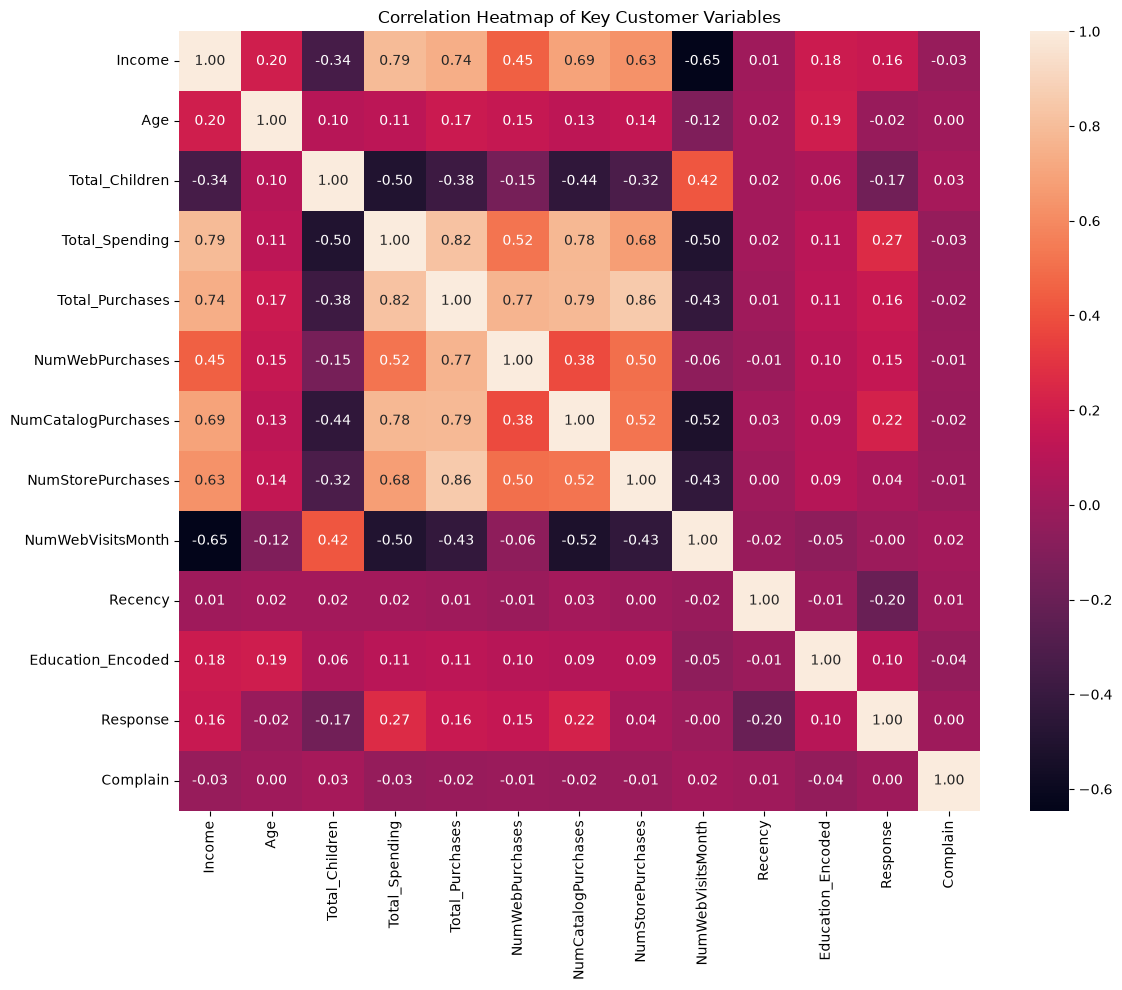

In [155]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    focused_corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key Customer Variables")
plt.tight_layout()
plt.show()

### Correlation Heatmap Findings

The correlation heatmap identified several notable relationships among customer demographics and purchasing behavior:

- Income has a strong positive correlation with total spending (0.79) and total purchases (0.74). Income is also positively associated with web purchases (0.45), catalog purchases (0.69), and store purchases (0.63).
- Total spending and total purchases are strongly positively correlated (0.82).
- Total purchases are strongly correlated with web purchases (0.77), catalog purchases (0.79), and store purchases (0.86). These strong relationships are expected because the three purchase channels are used to calculate `Total_Purchases`.
- Total children has a moderate negative correlation with total spending (-0.50) and weaker negative correlations with total purchases (-0.38), catalog purchases (-0.44), store purchases (-0.32), and web purchases (-0.15).
- Total children has a positive correlation with monthly web visits (0.42), suggesting that customers with more children tend to visit the website more frequently, although this does not necessarily result in more web purchases.
- Income has a strong negative correlation with monthly web visits (-0.65), while remaining positively associated with web purchases (0.45).
- Age has only weak positive correlations with both store purchases (0.14) and web purchases (0.15), so the heatmap alone does not provide strong evidence that older customers prefer physical stores.
- Total spending has a weak-to-moderate positive correlation with response to the most recent campaign (0.27).
- Recency has a weak negative correlation with campaign response (-0.20).

These correlations represent associations between variables and do not establish causal relationships.

# 13. Hypothesis Testing

Statistical hypothesis tests are performed to evaluate whether patterns observed in the sample provide sufficient evidence to support specific claims about customer purchasing behavior.

In [158]:
correlation, p_value = spearmanr(
    df["Age"],
    df["NumStorePurchases"]
)

In [159]:
print("Spearman correlation:", correlation)
print("P-value:", p_value)

Spearman correlation: 0.17078731782239592
P-value: 4.187146480328644e-16


## 13.1 Hypothesis 1: Age and In-Store Purchases

**H₀ (Null Hypothesis):** Customer age is not positively associated with the number of in-store purchases.

**H₁ (Alternative Hypothesis):** Customer age is positively associated with the number of in-store purchases.

A Spearman rank correlation test is used to evaluate the relationship between customer age and the number of store purchases.

### Conclusion

The Spearman correlation coefficient is approximately 0.171, indicating a weak positive relationship between customer age and the number of in-store purchases. The p-value is substantially below the 0.05 significance level, so the null hypothesis is rejected.

Therefore, the data provides statistically significant evidence that older customers tend to make slightly more in-store purchases. However, the relationship is weak, and the analysis does not establish that technological proficiency is the cause of this behavior.

## 13.2 Hypothesis 2: Children and Online Purchases

**H₀ (Null Hypothesis):** Customers with children do not make more web purchases than customers without children.

**H₁ (Alternative Hypothesis):** Customers with children make more web purchases than customers without children.

Customers are divided into two groups based on whether they have children at home. Their web purchasing behavior is then compared statistically.

In [ ]:
no_children = df.loc[
    df["Total_Children"] == 0,
    "NumWebPurchases"
]

has_children = df.loc[
    df["Total_Children"] > 0,
    "NumWebPurchases"
]

In [161]:
print("Customers without children:", len(no_children))
print("Customers with children:", len(has_children))

print("Average web purchases - No children:", no_children.mean())
print("Average web purchases - Has children:", has_children.mean())

Customers without children: 637
Customers with children: 1600
Average web purchases - No children: 4.39403453689168
Average web purchases - Has children: 3.965


In [ ]:
statistic, p_value = mannwhitneyu(
    has_children,
    no_children,
    alternative="greater"
    )

print("Mann-Whitney U statistic:", statistic)
print("P-value:", p_value)

Mann-Whitney U statistic: 435080.5
P-value: 0.9999999746807697


### Conclusion

Customers without children averaged approximately 4.39 web purchases, compared with approximately 3.97 web purchases for customers with children.

The one-sided Mann-Whitney U test produced a p-value of approximately 1.00, which is greater than the 0.05 significance level. Therefore, the null hypothesis is not rejected.

The data does not provide evidence that customers with children make more online purchases than customers without children. In this dataset, the observed average number of web purchases is actually slightly lower among customers with children.

## 13.3 Hypothesis 3: Store Purchase Cannibalization

**H₀ (Null Hypothesis):** Increased purchasing through alternative channels is not negatively associated with in-store purchases.

**H₁ (Alternative Hypothesis):** Increased purchasing through alternative channels is negatively associated with in-store purchases, which would be consistent with channel cannibalization.

Web and catalog purchases are combined to represent alternative purchasing channels. A Spearman rank correlation test is used to examine their relationship with store purchases.

In [165]:
df["Alternative_Channel_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
)

In [166]:
print(
    "Average alternative-channel purchases:",
    df["Alternative_Channel_Purchases"].mean()
)

print(
    "Average store purchases:",
    df["NumStorePurchases"].mean()
)

Average alternative-channel purchases: 6.749664729548503
Average store purchases: 5.794367456414841


In [167]:
correlation, p_value = spearmanr(
    df["Alternative_Channel_Purchases"],
    df["NumStorePurchases"],
    alternative="less"
)

print("Spearman correlation:", correlation)
print("P-value:", p_value)

Spearman correlation: 0.7374712899986486
P-value: 1.0


### Conclusion

The Spearman correlation between alternative-channel purchases and store purchases is approximately 0.737, indicating a strong positive association.

Because the hypothesis test specifically examined whether alternative-channel purchases were negatively associated with store purchases, the resulting p-value of 1.00 is greater than the 0.05 significance level. Therefore, the null hypothesis is not rejected.

The data does not provide evidence of store-purchase cannibalization. Instead, customers who make more purchases through web and catalog channels also tend to make more purchases in physical stores. This suggests that higher-purchasing customers may be active across multiple channels.

However, this correlation alone cannot determine whether one sales channel causally affects another.

## 13.4 Hypothesis 4: U.S. vs. Rest of World Purchase Volume

**H₀ (Null Hypothesis):** U.S. customers do not have a higher average total purchase volume than customers in the rest of the world.

**H₁ (Alternative Hypothesis):** U.S. customers have a higher average total purchase volume than customers in the rest of the world.

U.S. customers are compared with all non-U.S. customers using their total purchases across web, catalog, and store channels.

In [168]:
us_purchases = df.loc[
    df["Country"] == "US",
    "Total_Purchases"
]

rest_world_purchases = df.loc[
    df["Country"] != "US",
    "Total_Purchases"
]

In [169]:
print("Number of U.S. customers:", len(us_purchases))
print("Number of non-U.S. customers:", len(rest_world_purchases))

print("Average purchases - U.S.:", us_purchases.mean())
print("Average purchases - Rest of world:", rest_world_purchases.mean())

Number of U.S. customers: 109
Number of non-U.S. customers: 2128
Average purchases - U.S.: 13.513761467889909
Average purchases - Rest of world: 12.49436090225564


In [171]:
t_statistic, p_value = ttest_ind(
    us_purchases,
    rest_world_purchases,
    equal_var=False,
    alternative="greater"
)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 1.4577513613487312
P-value: 0.07376458593146705


### Conclusion

U.S. customers averaged approximately 13.51 total purchases, compared with approximately 12.49 purchases for customers in the rest of the world.

Welch's independent-samples t-test produced a t-statistic of approximately 1.46 and a one-sided p-value of approximately 0.074. Because the p-value is greater than the 0.05 significance level, the null hypothesis is not rejected.

Although U.S. customers had a higher average number of purchases in this sample, there is insufficient statistical evidence at the 5% significance level to conclude that U.S. customers significantly outperform customers in the rest of the world.

# 14. Business Visualizations

Visualizations are created to answer key business questions related to product performance, campaign response, customer demographics, and purchasing behavior.

## 14.1 Product Revenue Performance

Total customer spending is aggregated across each product category to identify the highest- and lowest-performing products.

In [172]:
product_revenue = df[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds"
    ]
].sum()

product_revenue

MntWines            680038
MntFruits            58767
MntMeatProducts     373393
MntFishProducts      83939
MntSweetProducts     60553
MntGoldProds         98358
dtype: int64

In [173]:
product_revenue = product_revenue.sort_values(ascending=False)

product_revenue

MntWines            680038
MntMeatProducts     373393
MntGoldProds         98358
MntFishProducts      83939
MntSweetProducts     60553
MntFruits            58767
dtype: int64

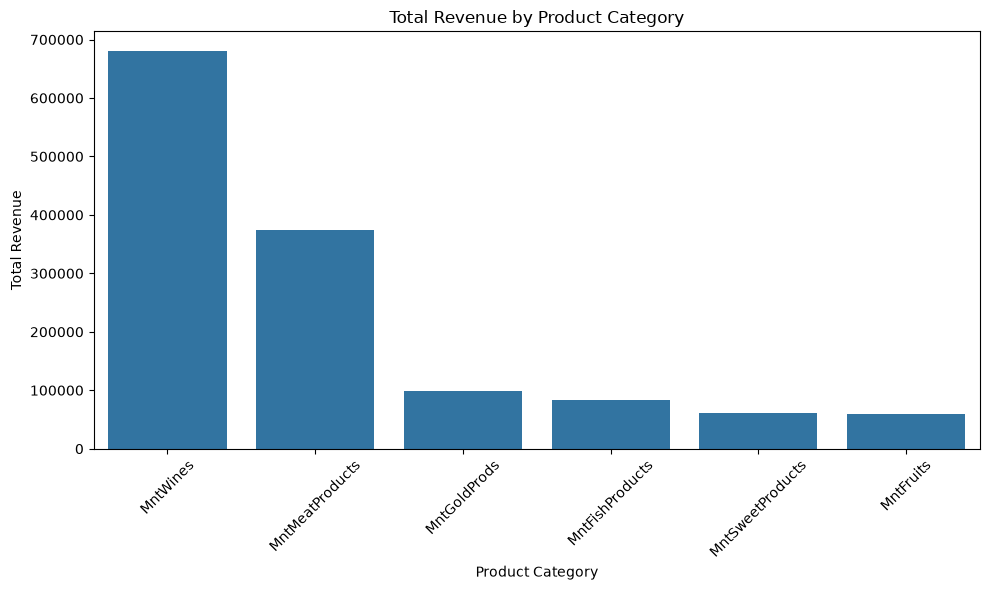

In [174]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_revenue.index,
    y=product_revenue.values
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Product Revenue Findings

Wine products generated the highest total revenue at 680,038, followed by meat products at 373,393. Gold products ranked third at 98,358.

Fruit products generated the lowest total revenue at 58,767, followed by sweet products at 60,553.

Overall, wine and meat products account for substantially more customer spending than the other product categories, indicating that these are the strongest-performing product categories in the dataset.

## 14.2 Age and Campaign Acceptance

The relationship between customer age and acceptance of the most recent marketing campaign is examined. Because `Response` is binary, the mean response for each age represents the campaign acceptance rate for customers of that age.

In [175]:
age_response = (
    df.groupby("Age")["Response"]
    .mean()
    .reset_index()
)

age_response.head(10)

,Age,Response
0,18,0.500000
1,19,0.200000
2,20,0.333333
3,21,0.400000
4,22,0.076923
5,23,0.266667
6,24,0.222222
7,25,0.033333
8,26,0.068966
9,27,0.222222


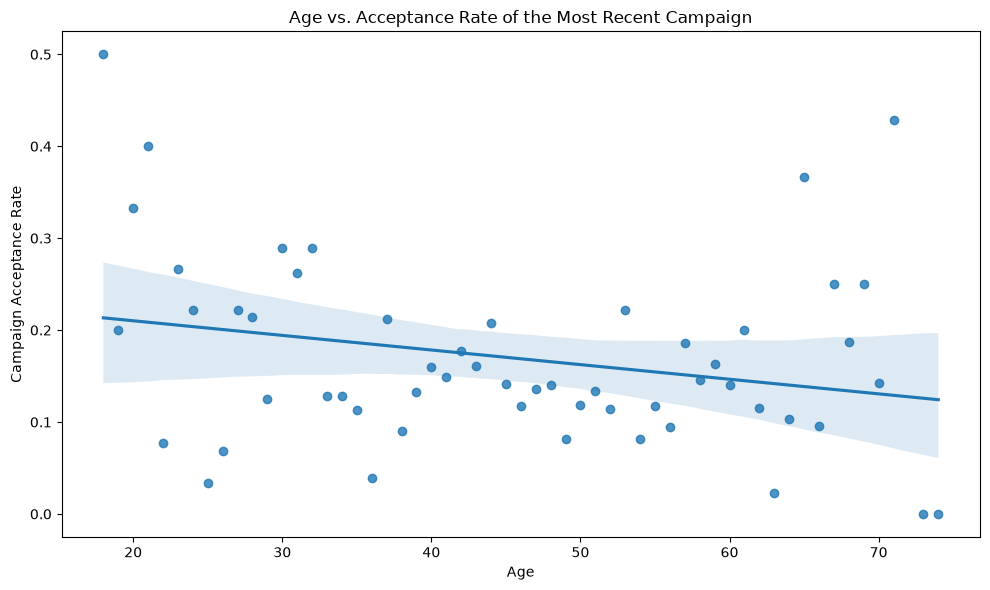

In [176]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=age_response,
    x="Age",
    y="Response"
)

plt.title("Age vs. Acceptance Rate of the Most Recent Campaign")
plt.xlabel("Age")
plt.ylabel("Campaign Acceptance Rate")

plt.tight_layout()
plt.show()

### Age and Campaign Acceptance Findings

The regression line shows a slight downward trend in campaign acceptance as customer age increases, suggesting that younger customers may have somewhat higher acceptance rates for the most recent campaign.

However, acceptance rates vary considerably across individual ages, and the overall relationship appears weak. Therefore, age alone does not appear to be a strong predictor of campaign acceptance.

## 14.3 Campaign Acceptance by Country

The number of customers who accepted the most recent marketing campaign is compared across countries to identify the country with the highest number of campaign acceptances.

In [177]:
country_acceptance = (
    df.loc[df["Response"] == 1, "Country"]
    .value_counts()
)

country_acceptance

Country
SP     176
SA      52
CA      38
AUS     23
GER     17
IND     13
US      13
ME       2
Name: count, dtype: int64

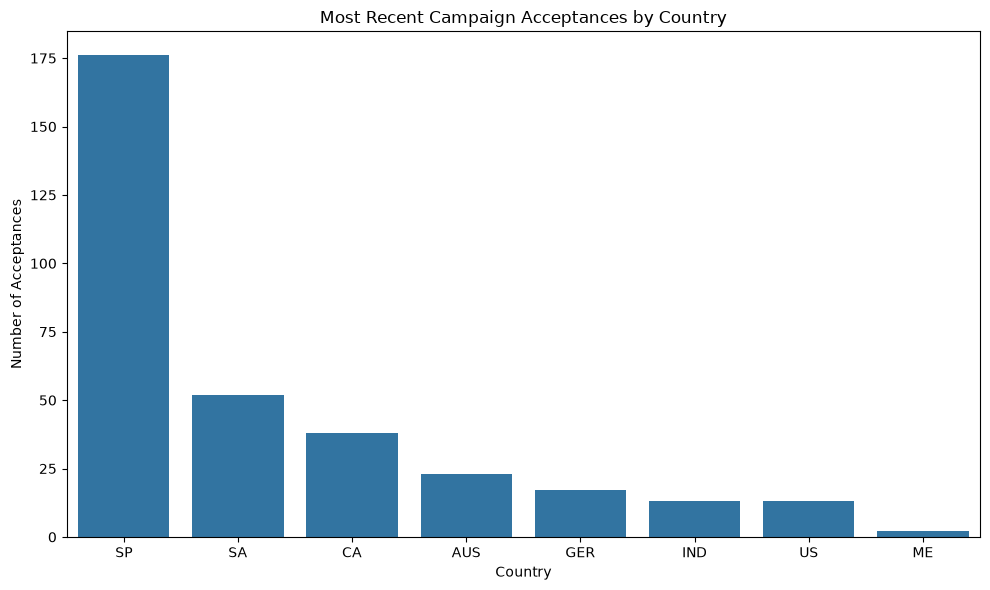

In [178]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_acceptance.index,
    y=country_acceptance.values
)

plt.title("Most Recent Campaign Acceptances by Country")
plt.xlabel("Country")
plt.ylabel("Number of Acceptances")

plt.tight_layout()
plt.show()

### Campaign Acceptance by Country Findings

SP had the highest number of customers who accepted the most recent marketing campaign, with 176 acceptances. SA ranked second with 52 acceptances, followed by CA with 38.

These values represent the total number of campaign acceptances rather than the acceptance rate within each country. Therefore, the results are influenced by differences in the number of customers represented by each country.

## 14.4 Children at Home and Total Expenditure

Customer spending is compared across the number of children in the household to determine whether a pattern exists between children at home and total expenditure.

In [179]:
children_spending = (
    df.groupby("Total_Children")["Total_Spending"]
    .agg(["count", "mean", "median"])
)

children_spending

,count,mean,median
Total_Children,,,
0,637,1104.857143,1189.0
1,1126,473.495560,306.0
2,421,245.947743,93.0
3,53,274.603774,88.0


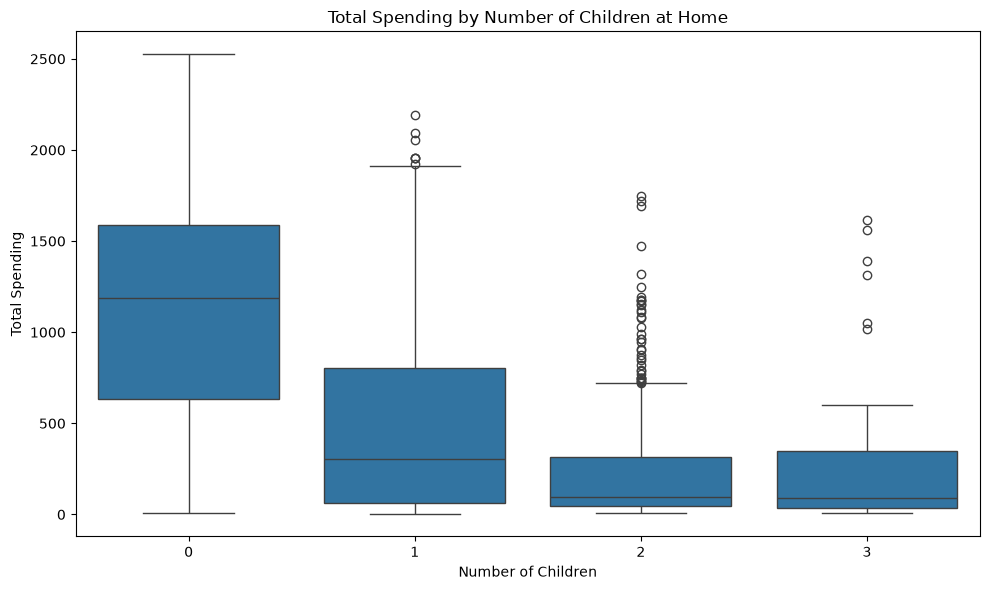

In [180]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Total_Children",
    y="Total_Spending"
)

plt.title("Total Spending by Number of Children at Home")
plt.xlabel("Number of Children")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

### Children and Total Spending Findings

Customers without children have substantially higher total spending than customers with children. Median spending decreases from approximately 1,189 among customers with no children to 306 for customers with one child, 93 for customers with two children, and 88 for customers with three children.

The box plot also shows several higher-spending observations among customers with children, particularly in the two- and three-child groups. However, the overall pattern indicates that customers with children generally spend less than customers without children.

This pattern is consistent with the earlier negative correlation between total children and total spending.

## 14.5 Educational Background of Customers Who Complained

The educational backgrounds of customers who lodged complaints are examined to determine which education groups are most represented among customers who reported a complaint.

In [181]:
complaint_education = (
    df.loc[df["Complain"] == 1, "Education"]
    .value_counts()
)

complaint_education

Education
Graduation    14
2n Cycle       3
Master         2
PhD            1
Name: count, dtype: int64

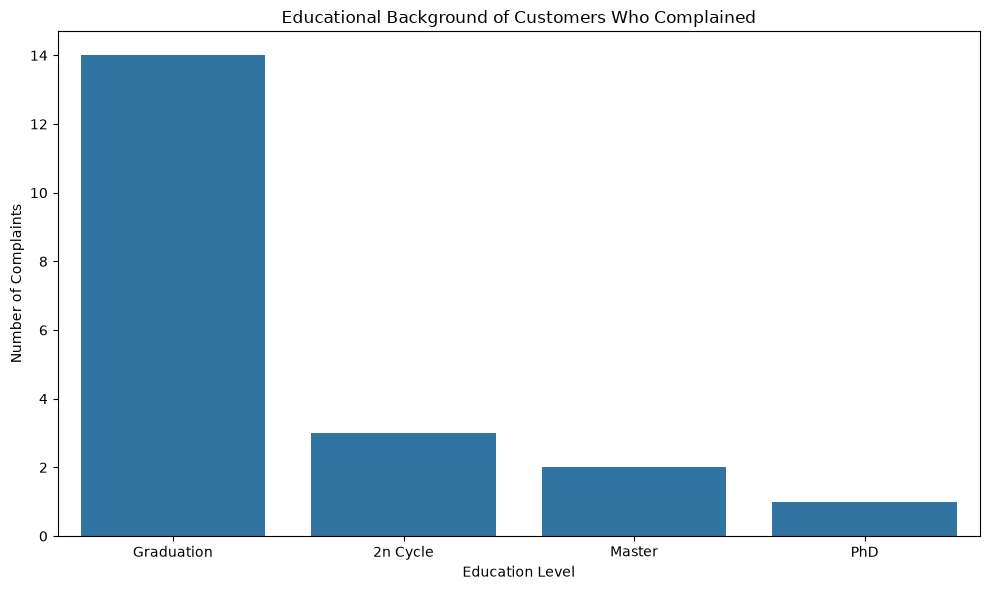

In [182]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=complaint_education.index,
    y=complaint_education.values
)

plt.title("Educational Background of Customers Who Complained")
plt.xlabel("Education Level")
plt.ylabel("Number of Complaints")

plt.tight_layout()
plt.show()

### Education and Complaint Findings

Among customers who lodged complaints, 14 had a Graduation-level education, 3 were in the 2n Cycle category, 2 had a Master's degree, and 1 had a PhD. No customers with a Basic education level were represented among the complaint records.

Graduation was therefore the most common educational background among customers who complained. However, Graduation is also the largest education group in the overall dataset, so these counts should not be interpreted as evidence that Graduation-level customers have a higher likelihood of complaining.

# 15. Final Findings and Business Recommendations

The exploratory analysis and hypothesis testing identified several important patterns in customer demographics, purchasing behavior, product performance, and marketing campaign response.

## Key Findings

- **Product Performance:** Wine was the highest-performing product category, generating total revenue of 680,038, followed by meat products at 373,393. Fruit products generated the lowest revenue at 58,767.

- **Income and Purchasing:** Income was strongly positively associated with both total spending and total purchases. Higher-income customers generally purchased and spent more across the available sales channels.

- **Children and Spending:** Customers without children spent substantially more than customers with children. Median spending decreased from 1,189 among customers with no children to 306 with one child, 93 with two children, and 88 with three children.

- **Age and Store Purchases:** A Spearman correlation test identified a statistically significant but weak positive relationship between age and in-store purchases. Older customers therefore tended to make slightly more store purchases, although the relationship was weak.

- **Children and Online Shopping:** The hypothesis that customers with children make more web purchases was not supported. Customers without children averaged approximately 4.39 web purchases compared with 3.97 among customers with children.

- **Channel Cannibalization:** The analysis did not provide evidence that web and catalog purchases were cannibalizing physical-store purchases. Alternative-channel and store purchases instead had a strong positive association, suggesting that higher-purchasing customers tend to use multiple channels.

- **U.S. Purchase Performance:** U.S. customers averaged approximately 13.51 total purchases compared with 12.49 among customers in the rest of the world. However, this difference was not statistically significant at the 0.05 significance level.

- **Campaign Response and Age:** Campaign acceptance showed only a weak relationship with age. The visualization suggested a slight decline in acceptance with increasing age, but age alone does not appear to be a strong predictor of campaign response.

- **Campaign Response by Country:** SP generated the highest number of acceptances for the most recent campaign with 176. Because countries contain different numbers of customers, these totals should not be interpreted as country-level acceptance rates.

- **Customer Complaints:** Graduation was the most common educational background among customers who complained. However, Graduation was also the largest education category in the dataset, so complaint counts alone do not indicate a higher likelihood of complaining.

## Business Recommendations

The company should prioritize wine and meat products because these categories generate substantially more revenue than the remaining product categories. Lower-performing categories such as fruits and sweets may benefit from targeted promotions, product bundling, or further investigation into customer demand.

Higher-income customers represent an important customer segment because income is strongly associated with both spending and purchasing activity. Marketing campaigns could use customer income and purchasing history to identify high-value customer segments.

Customers without children demonstrate substantially higher overall spending and may represent a particularly valuable segment for premium or discretionary product campaigns. Customers with children may require different offers, pricing strategies, or product combinations based on their lower observed spending levels.

The positive relationship between physical and alternative purchasing channels suggests that an omnichannel strategy may be more appropriate than treating web, catalog, and physical stores as competing channels. Customers who purchase frequently appear to engage across multiple channels.

Finally, customer age alone appears to provide limited predictive value for campaign acceptance. Future campaign targeting should consider combining demographic characteristics with stronger behavioral indicators such as income, previous spending, purchase frequency, recency, and previous campaign responses.